In [1]:
from logger import logger
import config
from ultralytics import YOLO
import torch
from tqdm import tqdm
from pathlib import Path
import requests
import cv2
import numpy as np
import os
import uuid
import matplotlib.pyplot as plt




log=logger()


class YoloDetecter():
    
    
    
    def __init__(self,task:str="DETECTION",size:str="MEDIUM",device=None):
        
        log.info("checking task is valid or not")
        if task not in config.TASK_TYPES:
            raise ValueError(f"choose model from {config.TASK_TYPES}")
        
        log.info("checking model size is valid or not")
        if size not in config.MODEL_SIZES:
            raise ValueError(f"choose model size from {config.MODEL_SIZES}")
            
        self.task=task
        self.size=size
        self.device=device or ("cuda" if torch.cuda.is_available() else "cpu")
        
        self.model_dir="models"
        
        self.model_path=os.path.join(self.model_dir,f'yolo26{self.suffix_of_model()}_{self.task}.pt')
        
        
        self.create_model_dir()
    
        
        
    log.info("definig suffix of a model function")
        
    def suffix_of_model(self):
            suffix={"NANO":"n",
                         "SMALL":"s",
                         "MEDIUM":"m",
                          "LARGE":"l",
                          "XLARGE":"x"}
            return suffix[self.size]
        
    log.info("creatingg a function to define the models path")
        
    def create_model_dir(self):
                
                model_path=f"models"
                os.makedirs(model_path,exist_ok=True)
                return model_path
            
    
    def download_model(self):
        
        try:
                if os.path.exists(self.model_path):
                    log.info(f"self already present at {self.model_path}" )
                    return


   
                response = requests.get(config.MODEL_URLS[self.task][self.size], stream=True)
                response.raise_for_status()

       
                total_size = int(response.headers.get("content-length", 0))

                
                with open(self.model_path, "wb") as file, tqdm(
                    total=total_size,
                    unit="B",
                    unit_scale=True,
                    desc="Downloading",
                ) as pbar:
                    for chunk in response.iter_content(chunk_size=1024):
                        if chunk:
                            file.write(chunk)
                            pbar.update(len(chunk))

                print("Download completed!")

                            
        except Exception as e:
        
                log.info(f'error : {e} raised during downloading')
                raise e
    
    

    def load_model(self):
        try:
                
                log.info(f'loading model')
                if os.path.exists(self.model_path):
                    pass
                else:
                    self.download_model()
                
                self.model=YOLO(self.model_path)
                self.model.to(self.device)
                
                return self.model
             
                    
        except Exception as e:
            if str(e)=="out of memory":
                self.device="cpu"
                self.model=YOLO(self.model_path)
                log.info(f"model {self.model} loaded with sufffix({self.suffix_of_model}) on device {self.device} ")
                return self.model
            else:
                log.info(f"error occured in load_model function {e}")
                raise e
  



    def detect(self, image):
        model = self.load_model()
        results = model(image)

        for result in results:
            if result.boxes is None:
                return

            boxes = result.boxes
            scores = boxes.conf.cpu()
            cls_ids = boxes.cls.cpu()
            names = model.names

            log.info( "sort by confidence")
            sorted_idx = torch.argsort(scores, descending=True)
            top_k =  len(sorted_idx)
            top_idx = sorted_idx[:top_k]

            img = result.plot()
            h, w, _ = img.shape

            panel_width = 300
            canvas = np.zeros((h, w + panel_width, 3), dtype=np.uint8)
            canvas[:, :w] = img
            canvas[:, w:] = (30, 30, 30)

            y_offset = 40
            cv2.putText(
                canvas,
                "Top Predictions",
                (w + 20, y_offset),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (255, 255, 255),
                2
            )

            y_offset += 30
            for i in range(top_k):
                cls_id = int(cls_ids[top_idx[i]])
                conf = float(scores[top_idx[i]])
                label = f"{i+1}. {names[cls_id]}: {conf:.2f}"

                cv2.putText(
                    canvas,
                    label,
                    (w + 20, y_offset + i * 40),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0, 255, 0),
                    2
                )
            
        canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 8))
        plt.imshow(canvas_rgb)
        plt.axis("off")
        plt.show()

          
        
    def segment_image(self,img):
        model=self.load_model()
        results=model(img)
        if results[0].masks is None:
            return
        
        img = cv2.imread(img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
       
        combined_mask = np.zeros(img.shape[:2], dtype=np.uint8)

        for mask in results[0].masks.data:
            m = mask.cpu().numpy()
            m = cv2.resize(m, (img.shape[1], img.shape[0]))
            combined_mask = np.maximum(combined_mask, (m > 0.5).astype(np.uint8))

        segmented = img * combined_mask[:, :, None]

        plt.imshow(segmented)
        plt.axis("off")
        plt.show()
       
        
        
        
        
        
        
       
        
    






            
                
                
                
                
                
        


image 1/1 /home/user/projects_ds/yolo_web_app/image.png: 448x640 11 persons, 2 benchs, 6 ties, 2501.6ms
Speed: 3.4ms preprocess, 2501.6ms inference, 41.0ms postprocess per image at shape (1, 3, 448, 640)


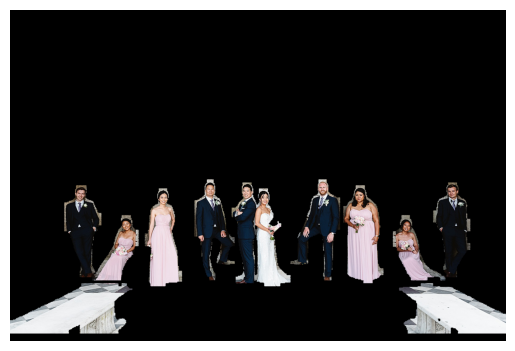

In [5]:
a=YoloDetecter(task="SEGMENTATION")

a.segment_image("image.png")
